In [1]:
import pandas as pd
import numpy as np
import pprint

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from itertools import combinations
from tqdm import tqdm 
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('data.csv')

In [3]:
# 'round', 'apparatus', 'location', 'days_before_event', 'score'
features = ['round', 'apparatus', 'location', 'days_before_event', 'fullname_mean']
target = 'score'

X = df[features]
y = df[target]

categorical_features = ['round', 'apparatus', 'location']
numeric_features = ['days_before_event', 'fullname_mean']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
# model = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
# ])

model.fit(X, y)

y_pred = model.predict(X)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print("RMSE:", rmse)

residual_std = np.std(y - y_pred)


RMSE: 0.7098691768733573


In [4]:
teams = {
#         'USA': ['Simone Biles',
#                 'Shilese Jones',
#                 'Konnor Mcclain',
#                 'Skye Blakely',
#                 'Jordan Chiles'],
        'GBR': ['Jessica Gadirova',
                'Alice Kinsella',
                'Ondine Achampong',
                'Georgia Mae Fenton',
                'Rebecca Downie'],
        'CAN': ['Elsabeth Black',
                'Emma Spence',
                'Aurelie Tran',
                'Sydney Leslie Turner',
                'Ava Stewart'],
        'BRA': ['Rebeca Andrade',
                'Flavia Saraiva',
                'Jade Barbosa',
                'Julia Das Neves Botega Soares',
                'Carolyne Mercer Winche Pedro'],
        'FRA': ['Melanie De Jesus Dos Santos',
                'Carolann Heduit',
                'Marine Boyer',
                'Aline Friess',
                'Morgane Osyssek Reimer'],
        'JPN': ['Shoko Miyata',
                'Ayaka Sakaguchi',
                'Rina Kishi',
                'Mana Okamura',
                'Chiharu Yamada'],
        'NED': ['Naomi Visser',
                'Eythora Thorsdottir',
                'Vera Van Pol',
                'Tisha Manouk Gijs Volleman',
                'Sanna Veerman'],
        'ITA': ['Alice D Amato',
                'Asia D Amato',
                'Martina Maggio',
                'Elisa Iorio',
                'Manila Esposito'],
        'AUS': ['Georgia Godwin',
                'Romi Brown',
                'Ruby Pass',
                'Emily Whitehead',
                'Macy Pegoli'],
        'ROU': ['Ana Barbosu',
                'Sabrina Maneca Voinea',
                'Amalia Ghigoarta',
                'Ioana Stanciulescu',
                'Andreea Preda'],
        'KOR': ['Yunseo Lee',
                'Seojeong Yeo',
                'Solyi Shin',
                'Dohyun Eom',
                'Dayeong Lee'],
        'CHN':['Zhuofan Huang', 'Ran Wu', 'Xiaoyuan Wei', 'Yaqin Zhou', 'Qiyuan Qiu']
    
}

select_country = 'USA'

In [5]:
df = df[
    (df['country'] == select_country) |
    (df.apply(lambda row: (row['country'] in teams) and (row['fullname'] in teams[row['country']]), axis=1))
]

In [6]:
fullname_dict = dict(zip(df['fullname'], df['fullname_mean']))

pred_teamfinal = {}
pred_AAfinal = {}
pred_final = {}
pred_qual = {}


for idx, row in df.iterrows():
    athlete = row['fullname']
    app = row['apparatus']
    key = f"{athlete}_{app}" 

    
    input_df_teamfinal = pd.DataFrame({
        'round': ['TeamFinal'],
        'apparatus': [app],
        'location': ['France'],
        'days_before_event': [0],
        'fullname_mean': [fullname_dict.get(athlete)]
    })
    pred_teamfinal[key] = model.predict(input_df_teamfinal)[0]

    
    input_df_AAfinal = pd.DataFrame({
        'round': ['AAfinal'],
        'apparatus': [app],
        'location': ['France'],
        'days_before_event': [0],
        'fullname_mean': [fullname_dict.get(athlete)]
    })
    pred_AAfinal[key] = model.predict(input_df_AAfinal)[0]

    input_df_final = pd.DataFrame({
        'round': ['final'],
        'apparatus': [app],
        'location': ['France'],
        'days_before_event': [0],
        'fullname_mean': [fullname_dict.get(athlete)]
    })
    pred_final[key] = model.predict(input_df_final)[0]

    input_df_qual = pd.DataFrame({
        'round': ['qual'],
        'apparatus': [app],
        'location': ['France'],
        'days_before_event': [0],
        'fullname_mean': [fullname_dict.get(athlete)]
    })
    pred_qual[key] = model.predict(input_df_qual)[0]


In [7]:
def get_predicted_score(fullname, apparatus, round_, seed=None):
    """
    根据运动员的 fullname、apparatus 和 round_ 得到预测成绩，并加上随机噪音。
    
    参数：
        fullname: 运动员姓名（字符串）
        apparatus: 运动项目（字符串）
        round_: 轮次（字符串），支持 'TeamFinal', 'AAfinal', 'final', 'qual'
    
    返回：
        加入噪音后的预测成绩（浮点数）。若找不到对应的预测成绩，则返回 0.
    """

     
    if seed is not None:
        np.random.seed(seed)
    
    key = f"{fullname}_{apparatus}"
    
    # 根据 round_ 选择对应的词典
    pred_dicts = {
        'TeamFinal': pred_teamfinal,
        'AAfinal': pred_AAfinal,
        'final': pred_final,
        'qual': pred_qual
    }
    
    if round_ not in pred_dicts:
        raise ValueError(f"不支持的轮次: {round_}")
    
    base_score = pred_dicts[round_].get(key)
    if base_score is None:
        # 没有找到对应的预测成绩时，返回 0
        return 0.0
    
    # 加入随机噪音，噪音尺度为 residual_std
    noise = np.random.normal(loc=0, scale=0.7)
    return base_score + noise


In [8]:

df_ch = df[df['country'] == select_country]

chinese_avg = df_ch.groupby('fullname')['score'].mean().reset_index()
chinese_avg = chinese_avg.sort_values(by='score', ascending=False)
top10_chinese = chinese_avg.head(10)['fullname'].tolist()

print("Top 10 athletes from qualification round:", top10_chinese)

Top 10 athletes from qualification round: ['Simone Biles', 'Shilese Jones', 'Konnor Mcclain', 'Sunisa Lee', 'Jade Carey', 'Jordan Chiles', 'Skye Blakely', 'Leanne Wong', 'Olivia Greaves', 'Kayla Dicello']


In [9]:
foreign_athletes = teams

# 设定比赛项目（资格赛和决赛均采用相同项目名称）
# 这里以常用缩写：VT（vault），UB（uneven bars），BB（balance beam），FX（floor exercise）
apparatuses = ['VT', 'UB', 'BB', 'FX']

# ----------------= 模拟函数 -----------------
def simulate_qualification(qual_athletes):
    qual_scores = {}
    for country, athletes in qual_athletes.items():
        qual_scores[country] = {}
        for athlete in athletes:
            qual_scores[country][athlete] = {}
            for app in apparatuses:
                # 直接调用 get_predicted_score 函数，指定 round 为 'qual'
                score = get_predicted_score(athlete, app, 'qual')
                qual_scores[country][athlete][app] = score
    return qual_scores

def determine_qualifiers(qual_scores):
    """
    根据资格赛得分决定晋级名单，返回三个晋级名单：
      - team_qualifiers: 团体资格，格式 [(country, team_score), ...]，按 team_score 降序，取前8
      - aa_qualifiers: 全能资格，格式 [(country, athlete, total_score), ...]，每国最多2人，总共前24
      - event_qualifiers: 单项资格，格式 { apparatus: [(country, athlete, score), ...] }，每项目前8
    """
    # (1) 团体资格：各国团队得分 = 对每个项目取该国所有运动员分数中的最高3个之和累加
    team_scores = {}
    for country, athletes in qual_scores.items():
        total = 0.0
        for app in apparatuses:
            scores = []
            for athlete, scores_dict in athletes.items():
                scores.append(scores_dict.get(app, 0))
            scores = sorted(scores, reverse=True)
            top3 = scores[:3]  
            total += sum(top3)
        team_scores[country] = total
    team_qualifiers = sorted(team_scores.items(), key=lambda x: x[1], reverse=True)[:8]
    
    aa_list = []
    for country, athletes in qual_scores.items():
        for athlete, scores_dict in athletes.items():
            total = sum(scores_dict.get(app, 0) for app in apparatuses)
            aa_list.append((country, athlete, total))
    aa_sorted = sorted(aa_list, key=lambda x: x[2], reverse=True)
    aa_qualifiers = []
    country_count = {}
    for country, athlete, total in aa_sorted:
        if country_count.get(country, 0) < 2:
            aa_qualifiers.append((country, athlete, total))
            country_count[country] = country_count.get(country, 0) + 1
        if len(aa_qualifiers) >= 24:
            break
            
    # (3) 单项资格：每个项目取前8
    event_qualifiers = {app: [] for app in apparatuses}
    for app in apparatuses:
        app_list = []
        for country, athletes in qual_scores.items():
            for athlete, scores_dict in athletes.items():
                app_list.append((country, athlete, scores_dict.get(app, 0)))
        event_qualifiers[app] = sorted(app_list, key=lambda x: x[2], reverse=True)[:8]
    
    return team_qualifiers, aa_qualifiers, event_qualifiers

def simulate_team_finals(teams_final):
    team_final_scores = {}
    for country, athletes in teams_final.items():
        total_score = 0.0
        for app in apparatuses:
            # 先从基础预测字典中获取每个运动员在该项目下 TeamFinal 轮次的基础预测成绩
            athlete_base_scores = []
            for athlete in athletes:
                key = f"{athlete}_{app}"
                base_score = pred_teamfinal.get(key)
                if base_score is not None:
                    athlete_base_scores.append((athlete, base_score))
            # 如果该项目没有数据，则跳过
            if not athlete_base_scores:
                continue
            # 按照基础预测成绩降序排序，并选择前三名
            athlete_base_scores.sort(key=lambda x: x[1], reverse=True)
            selected_athletes = [athlete for athlete, _ in athlete_base_scores[:3]]
            
            # 对选中的运动员，调用 get_predicted_score 模拟真实比赛成绩（考虑噪音）
            apparatus_score = 0.0
            for athlete in selected_athletes:
                simulated_score = get_predicted_score(athlete, app, 'TeamFinal')
                apparatus_score += simulated_score
            total_score += apparatus_score
        team_final_scores[country] = total_score
    return team_final_scores

def simulate_aa_finals(aa_qualifiers):
    aa_final_scores = []
    for country, athlete, _ in aa_qualifiers:
        total = 0.0
        for app in apparatuses:
            # 直接调用 get_predicted_score，指定 round 为 'AAfinal'
            total += get_predicted_score(athlete, app, 'AAfinal')
        aa_final_scores.append((country, athlete, total))
    return sorted(aa_final_scores, key=lambda x: x[2], reverse=True)

def simulate_event_finals(event_qualifiers):
    event_final_results = {}
    for app, qualifiers in event_qualifiers.items():
        scores_list = []
        for country, athlete, _ in qualifiers:
            # 直接调用 get_predicted_score，指定 round 为 'final'
            score = get_predicted_score(athlete, app, 'final')
            scores_list.append((country, athlete, score))
        event_final_results[app] = sorted(scores_list, key=lambda x: x[2], reverse=True)
    return event_final_results

In [10]:
def run_simulation(selected_team):
    """
    一次完整的模拟流程：
      1. 构造所有国家的参赛名单
      2. 模拟资格赛得分，并根据得分确定晋级名单
      3. 模拟决赛（团体、全能、单项），根据排名决定奖牌归属
      4. 返回本轮模拟各个决赛项目中获得的奖牌数，
         结构如下：
         {
           'overall': {'gold': X, 'silver': Y, 'bronze': Z},  # 合计所有项目
           'team_final': {'gold':0/1, 'silver':0/1, 'bronze':0/1},
           'aa_final': {'gold':0/1, 'silver':0/1, 'bronze':0/1},
           'event_final': {
               app1: {'gold':0/1, 'silver':0/1, 'bronze':0/1},
               app2: {'gold':0/1, 'silver':0/1, 'bronze':0/1},
               ...
           }
         }
    """
    

    
    qual_athletes = {}
    qual_athletes[select_country] = list(selected_team)
    for country, ath_list in foreign_athletes.items():
        qual_athletes[country] = ath_list

    # 模拟资格赛
    qual_scores = simulate_qualification(qual_athletes)
    # 根据资格赛结果确定晋级名单
    team_qualifiers, aa_qualifiers, event_qualifiers = determine_qualifiers(qual_scores)

    # ---------------- 团体决赛 ----------------
    # 中国队决赛阵容固定为 selected_team；其他国家使用资格赛中所有运动员
    teams_final = {}
    for country, _ in team_qualifiers:
        if country == select_country:
            teams_final[country] = list(selected_team)
        else:
            teams_final[country] = list(qual_scores[country].keys())
    team_final_scores = simulate_team_finals(teams_final)
    sorted_team_final = sorted(team_final_scores.items(), key=lambda x: x[1], reverse=True)
    team_medals = {}
    for i, (country, score) in enumerate(sorted_team_final[:3]):
        if i == 0:
            team_medals[country] = 'gold'
        elif i == 1:
            team_medals[country] = 'silver'
        elif i == 2:
            team_medals[country] = 'bronze'
    # 记录中国队在团体决赛中获得的奖牌（每轮只能获得一枚奖牌）
    team_final_medals = {'gold': 0, 'silver': 0, 'bronze': 0}
    if select_country in team_medals:
        team_final_medals[ team_medals[select_country] ] = 1

    # ---------------- 个人全能决赛 ----------------
    aa_final = simulate_aa_finals(aa_qualifiers)
    aa_medals = {}
    for i, (country, athlete, score) in enumerate(aa_final[:3]):
        if i == 0:
            aa_medals[(country, athlete)] = 'gold'
        elif i == 1:
            aa_medals[(country, athlete)] = 'silver'
        elif i == 2:
            aa_medals[(country, athlete)] = 'bronze'
    aa_final_medals = {'gold': 0, 'silver': 0, 'bronze': 0}
    for (country, athlete), medal in aa_medals.items():
        if country == select_country:
            aa_final_medals[medal] = 1  

    # ---------------- 单项决赛 ----------------
    event_final = simulate_event_finals(event_qualifiers)
    event_medals = {}
    for app, results in event_final.items():
        medals = {}
        for i, (country, athlete, score) in enumerate(results[:3]):
            if i == 0:
                medals[(country, athlete)] = 'gold'
            elif i == 1:
                medals[(country, athlete)] = 'silver'
            elif i == 2:
                medals[(country, athlete)] = 'bronze'
        event_medals[app] = medals
    event_final_medals = {}
    for app, medals in event_medals.items():
        event_final_medals[app] = {'gold': 0, 'silver': 0, 'bronze': 0}
        for (country, athlete), medal in medals.items():
            if country == select_country:
                event_final_medals[app][medal] = 1

    # ---------------- 计算整体奖牌数 ----------------
    overall = {'gold': 0, 'silver': 0, 'bronze': 0}
    for medal in overall:
        overall[medal] = team_final_medals[medal] + aa_final_medals[medal]
        # 累加所有单项的奖牌
        for app in event_final_medals:
            overall[medal] += event_final_medals[app][medal]

    return {
        'overall': overall,
        'team_final': team_final_medals,
        'aa_final': aa_final_medals,
        'event_final': event_final_medals
    }



In [11]:
def simulate_for_candidate(selected_team, num_simulations=100, seed=None):
    if seed is not None:
        np.random.seed(seed)
        
    overall_total = {'gold': 0, 'silver': 0, 'bronze': 0}
    team_total = {'gold': 0, 'silver': 0, 'bronze': 0}
    aa_total = {'gold': 0, 'silver': 0, 'bronze': 0}
    event_total = {}

    overall_medals = []  
    gold_medals = []
    silver_medals = []
    bronze_medals = []

    for _ in range(num_simulations):
        sim_result = run_simulation(selected_team)

        for medal in overall_total:
            overall_total[medal] += sim_result['overall'][medal]
            team_total[medal] += sim_result['team_final'][medal]
            aa_total[medal] += sim_result['aa_final'][medal]

        for app, medals in sim_result['event_final'].items():
            if app not in event_total:
                event_total[app] = {'gold': 0, 'silver': 0, 'bronze': 0}
            for medal in medals:
                event_total[app][medal] += medals[medal]

        overall_medals.append(sum(sim_result['overall'].values()))
        gold_medals.append(sim_result['overall']['gold'])
        silver_medals.append(sim_result['overall']['silver'])
        bronze_medals.append(sim_result['overall']['bronze'])

    overall_avg = {medal: overall_total[medal] / num_simulations for medal in overall_total}
    team_avg = {medal: team_total[medal] / num_simulations for medal in team_total}
    aa_avg = {medal: aa_total[medal] / num_simulations for medal in aa_total}
    event_avg = {app: {medal: medals[medal] / num_simulations for medal in medals} for app, medals in event_total.items()}

    return {
        'overall': overall_avg,
        'team_final': team_avg,
        'aa_final': aa_avg,
        'event_final': event_avg,
        'max_overall': max(overall_medals),
        'min_overall': min(overall_medals),
        'max_gold': max(gold_medals),
        'min_gold': min(gold_medals),
        'max_silver': max(silver_medals),
        'min_silver': min(silver_medals),
        'max_bronze': max(bronze_medals),
        'min_bronze': min(bronze_medals)
    }


candidate_teams = list(combinations(top10_chinese, 5))
simulation_results = []

print(f"开始对 {len(candidate_teams)} 种候选阵容进行模拟...")
for combo in tqdm(candidate_teams):
    avg_medals = simulate_for_candidate(combo, num_simulations=2000, seed=9)

    result_entry = {
        'combination': combo,
        'overall_gold': avg_medals['overall']['gold'],
        'overall_silver': avg_medals['overall']['silver'],
        'overall_bronze': avg_medals['overall']['bronze'],
        'overall_total': sum(avg_medals['overall'].values()),
        'max_overall': avg_medals['max_overall'],
        'min_overall': avg_medals['min_overall'],
        'max_gold': avg_medals['max_gold'],
        'min_gold': avg_medals['min_gold'],
        'max_silver': avg_medals['max_silver'],
        'min_silver': avg_medals['min_silver'],
        'max_bronze': avg_medals['max_bronze'],
        'min_bronze': avg_medals['min_bronze'],
        'team_gold': avg_medals['team_final']['gold'],
        'team_silver': avg_medals['team_final']['silver'],
        'team_bronze': avg_medals['team_final']['bronze'],
        'aa_gold': avg_medals['aa_final']['gold'],
        'aa_silver': avg_medals['aa_final']['silver'],
        'aa_bronze': avg_medals['aa_final']['bronze']
    }

    for app, medals in avg_medals['event_final'].items():
        result_entry[f"{app}_gold"] = medals['gold']
        result_entry[f"{app}_silver"] = medals['silver']
        result_entry[f"{app}_bronze"] = medals['bronze']

    simulation_results.append(result_entry)

results_df = pd.DataFrame(simulation_results)


开始对 252 种候选阵容进行模拟...


100%|████████████████████████████████████████████████████████████████████████████████| 252/252 [10:55<00:00,  2.60s/it]


In [12]:
sorted_results = results_df.sort_values(
    by=['overall_gold', 'overall_silver', 'overall_bronze'],
    ascending=[False, False, False]
)

print("\nBest Team candidate (in order of gold medal priority)：")
print(sorted_results.iloc[:,0:5].head(5).to_string(index=False))


Best Team candidate (in order of gold medal priority)：
                                                                 combination  overall_gold  overall_silver  overall_bronze  overall_total
    (Simone Biles, Shilese Jones, Konnor Mcclain, Sunisa Lee, Jordan Chiles)        3.5300          1.9055          1.3845         6.8200
       (Simone Biles, Shilese Jones, Konnor Mcclain, Sunisa Lee, Jade Carey)        3.5300          1.9045          1.3850         6.8195
     (Simone Biles, Shilese Jones, Konnor Mcclain, Sunisa Lee, Skye Blakely)        3.5085          1.8935          1.3340         6.7360
      (Simone Biles, Shilese Jones, Konnor Mcclain, Sunisa Lee, Leanne Wong)        3.5070          1.8880          1.3355         6.7305
(Simone Biles, Shilese Jones, Konnor Mcclain, Jordan Chiles, Olivia Greaves)        3.5050          1.8595          1.2950         6.6595


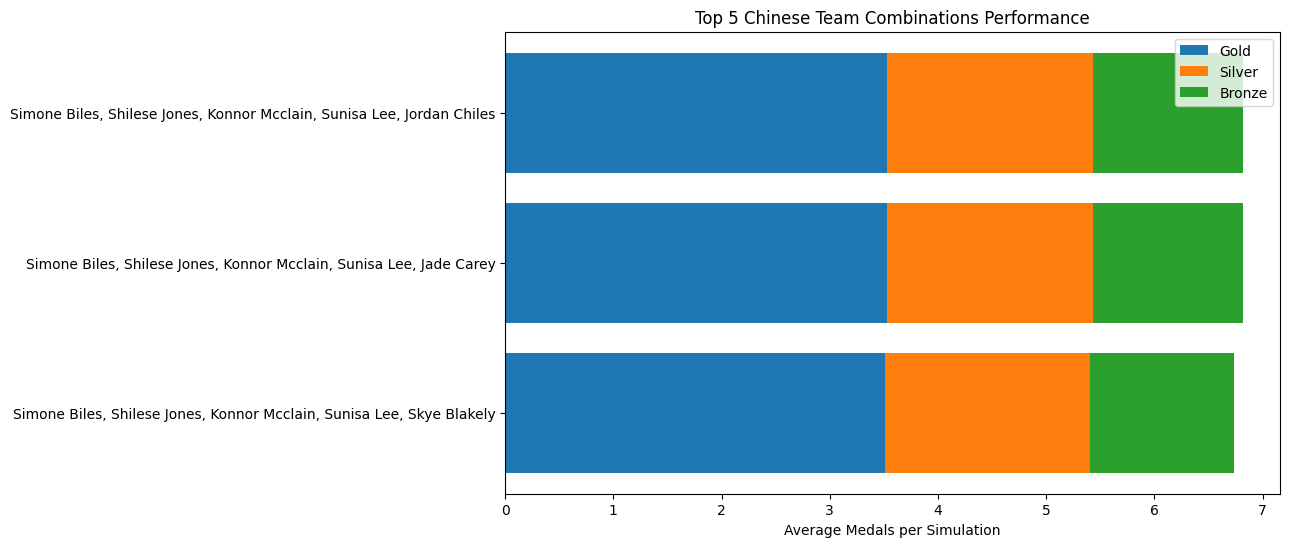

In [13]:


plt.figure(figsize=(10, 6))
top5 = sorted_results.head(3)
x_labels = [", ".join(combo) for combo in top5['combination']]
plt.barh(x_labels, top5['overall_gold'], label='Gold')
plt.barh(x_labels, top5['overall_silver'], left=top5['overall_gold'], label='Silver')
plt.barh(x_labels, top5['overall_bronze'], left=top5['overall_gold']+top5['overall_silver'], label='Bronze')
plt.xlabel('Average Medals per Simulation')
plt.title('Top 5 Chinese Team Combinations Performance')
plt.legend()
plt.gca().invert_yaxis()
plt.show()


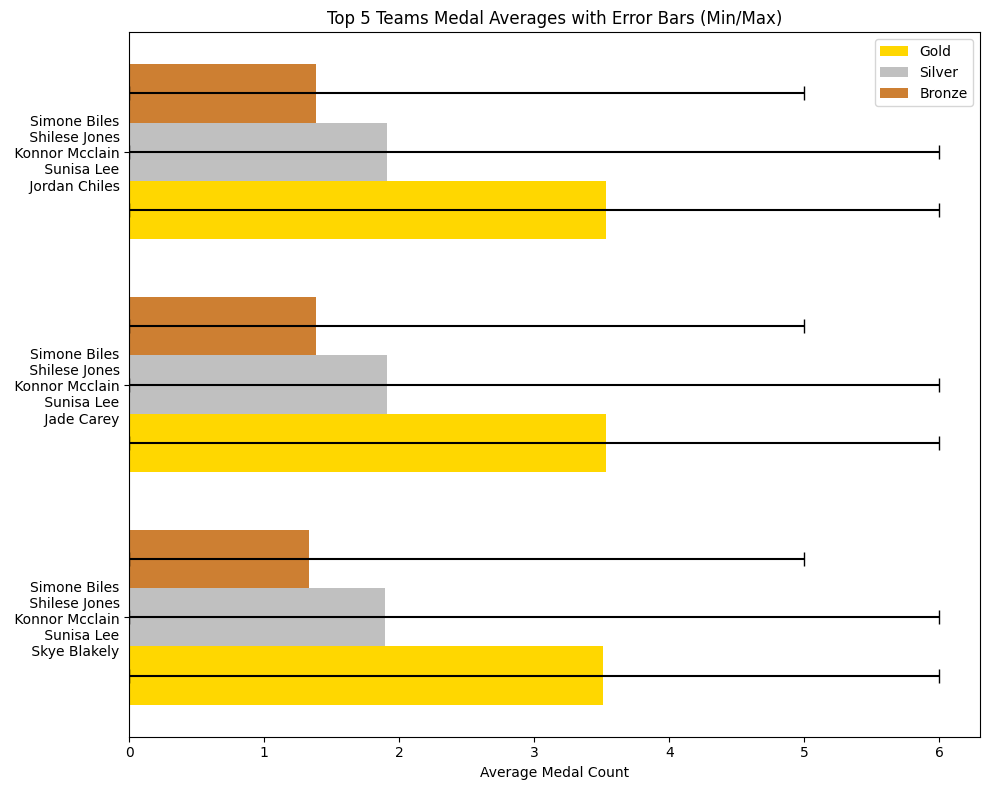

In [14]:
top5 = sorted_results.head(3).copy()[::-1]
x_labels = ["\n".join(combo.split(",")) for combo in x_labels[::-1]]
x = np.arange(len(x_labels))
width = 0.25  
overall_gold_err_lower = top5['overall_gold'] - top5['min_gold']
overall_gold_err_upper = top5['max_gold'] - top5['overall_gold']
silver_err_lower = top5['overall_silver'] - top5['min_silver']
silver_err_upper = top5['max_silver'] - top5['overall_silver']
bronze_err_lower = top5['overall_bronze'] - top5['min_bronze']
bronze_err_upper = top5['max_bronze'] - top5['overall_bronze']

fig, ax = plt.subplots(figsize=(10, 8))

# 水平条形图
ax.barh(x - width, top5['overall_gold'], height=width, label='Gold',
        xerr=[overall_gold_err_lower, overall_gold_err_upper], capsize=5, color='gold')
ax.barh(x, top5['overall_silver'], height=width, label='Silver',
        xerr=[silver_err_lower, silver_err_upper], capsize=5, color='silver')
ax.barh(x + width, top5['overall_bronze'], height=width, label='Bronze',
        xerr=[bronze_err_lower, bronze_err_upper], capsize=5, color='#cd7f32')

# 设置Y轴标签
ax.set_yticks(x)
ax.set_yticklabels(x_labels)

# 添加标题和标签
ax.set_xlabel('Average Medal Count')
ax.set_title('Top 5 Teams Medal Averages with Error Bars (Min/Max)')
ax.legend()

plt.tight_layout()
plt.show()


In [15]:
sorted_results.columns

Index(['combination', 'overall_gold', 'overall_silver', 'overall_bronze',
       'overall_total', 'max_overall', 'min_overall', 'max_gold', 'min_gold',
       'max_silver', 'min_silver', 'max_bronze', 'min_bronze', 'team_gold',
       'team_silver', 'team_bronze', 'aa_gold', 'aa_silver', 'aa_bronze',
       'VT_gold', 'VT_silver', 'VT_bronze', 'UB_gold', 'UB_silver',
       'UB_bronze', 'BB_gold', 'BB_silver', 'BB_bronze', 'FX_gold',
       'FX_silver', 'FX_bronze'],
      dtype='object')

In [16]:
data = sorted_results.head(1)

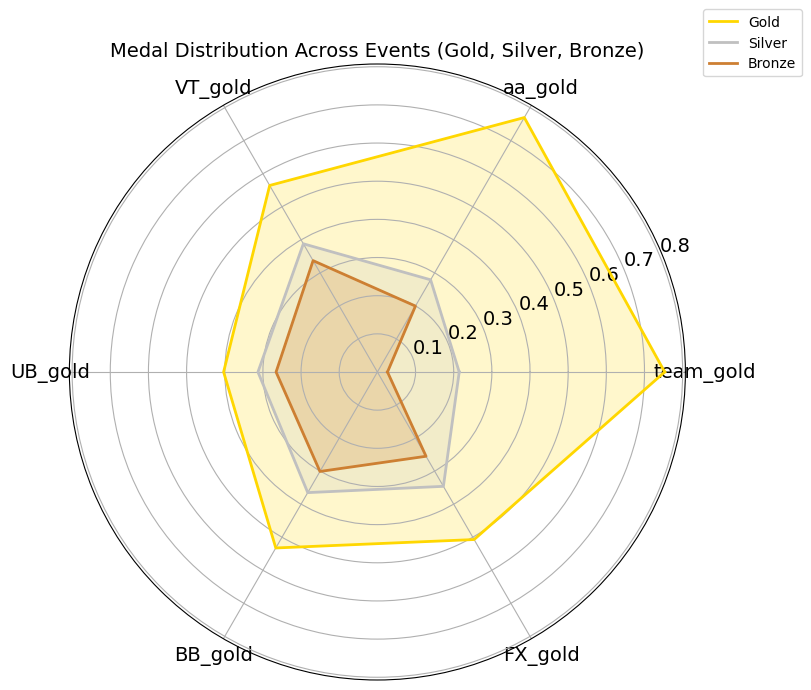

In [17]:
categories = ['team_gold', 'aa_gold', 'VT_gold', 'UB_gold', 'BB_gold', 'FX_gold']

gold_values = data[categories].mean().values
silver_values = data[[c.replace('gold', 'silver') for c in categories]].mean().values
bronze_values = data[[c.replace('gold', 'bronze') for c in categories]].mean().values

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

gold_values = np.append(gold_values, gold_values[0])
silver_values = np.append(silver_values, silver_values[0])
bronze_values = np.append(bronze_values, bronze_values[0])

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
ax.plot(angles, gold_values, color='gold', linewidth=2, label='Gold')
ax.fill(angles, gold_values, color='gold', alpha=0.2)

ax.plot(angles, silver_values, color='silver', linewidth=2, label='Silver')
ax.fill(angles, silver_values, color='silver', alpha=0.2)

ax.plot(angles, bronze_values, color='#cd7f32', linewidth=2, label='Bronze')
ax.fill(angles, bronze_values, color='#cd7f32', alpha=0.2)

plt.xticks(angles[:-1], categories, fontsize=14)  
plt.title('Medal Distribution Across Events (Gold, Silver, Bronze)', fontsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()

In [18]:
sorted_results.columns

Index(['combination', 'overall_gold', 'overall_silver', 'overall_bronze',
       'overall_total', 'max_overall', 'min_overall', 'max_gold', 'min_gold',
       'max_silver', 'min_silver', 'max_bronze', 'min_bronze', 'team_gold',
       'team_silver', 'team_bronze', 'aa_gold', 'aa_silver', 'aa_bronze',
       'VT_gold', 'VT_silver', 'VT_bronze', 'UB_gold', 'UB_silver',
       'UB_bronze', 'BB_gold', 'BB_silver', 'BB_bronze', 'FX_gold',
       'FX_silver', 'FX_bronze'],
      dtype='object')

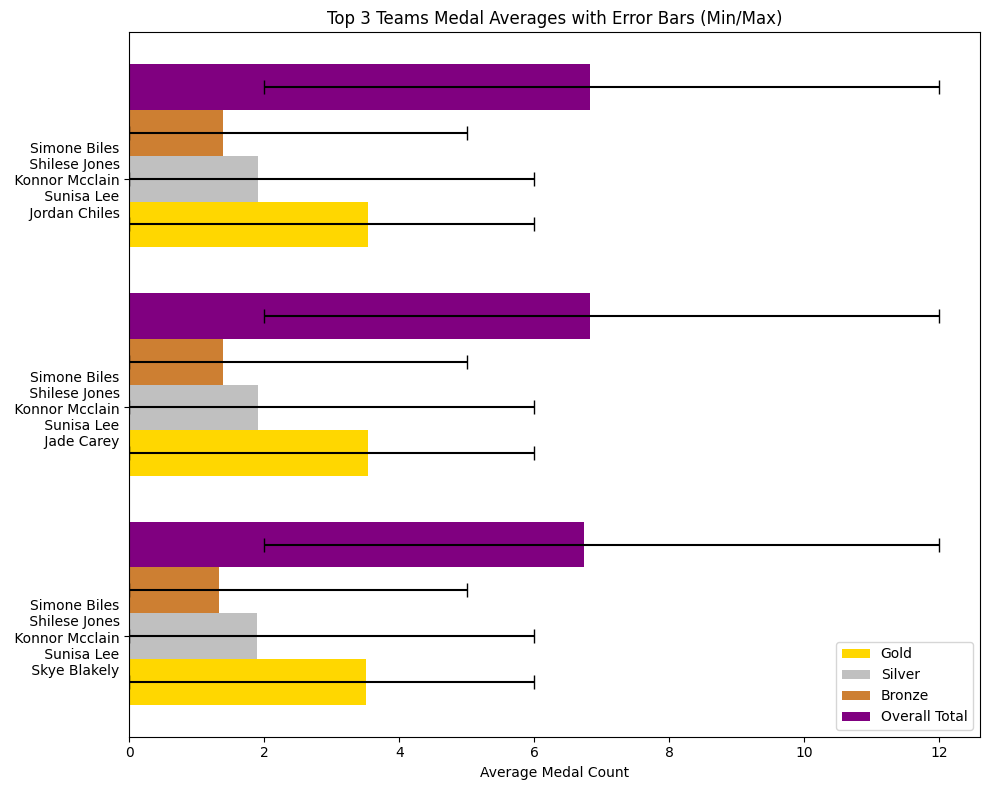

In [19]:
fig, ax = plt.subplots(figsize=(10, 8))
overall_err_lower = top5['overall_total'] - top5['min_overall']
overall_err_upper = top5['max_overall'] - top5['overall_total']
# 颜色设置
colors = {'Gold': 'gold', 'Silver': 'silver', 'Bronze': '#cd7f32', 'Overall':'purple'}
width = 0.2
# 水平条形图 (金银铜)
ax.barh(x - width, top5['overall_gold'], height=width, label='Gold',
        xerr=[overall_gold_err_lower, overall_gold_err_upper], capsize=5, color=colors['Gold'])
ax.barh(x, top5['overall_silver'], height=width, label='Silver',
        xerr=[silver_err_lower, silver_err_upper], capsize=5, color=colors['Silver'])

ax.barh(x + width, top5['overall_bronze'], height=width, label='Bronze',
        xerr=[bronze_err_lower, bronze_err_upper], capsize=5, color=colors['Bronze'])

ax.barh(x + 2* width, top5['overall_total'], height=width, label='Overall Total',
        xerr=[overall_err_lower, overall_err_upper], capsize=5, color=colors['Overall'])


# 设置Y轴标签
ax.set_yticks(x)
ax.set_yticklabels(x_labels)

# 添加标题和标签
ax.set_xlabel('Average Medal Count')
ax.set_title('Top 3 Teams Medal Averages with Error Bars (Min/Max)')
ax.legend(loc='best')

plt.tight_layout()
plt.show()